In [4]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.io
import pandas as pd
import glob
import os
import rasterio as rio
from sklearn.metrics import r2_score, mean_squared_error 

In [5]:
def read_ground_data_mat(filepath):
    rd = scipy.io.loadmat(filepath) # load the mat file
    DATA = rd['DATA']
    x = rd['X']
    y = rd['Y']
    
    return DATA, x, y

In [6]:
def euclidian_dist(x1,y1,x2,y2):
    import numpy as np
    dist = np.sqrt((x2-x1)**2 + (y2-y1)**2)
    return dist

In [7]:
# ground data files
ground_data_folder = '/Users/jukesliu/Documents/POSTDOC/snow-radar/ReynoldsMountain/ground_data/'
os.listdir(ground_data_folder)

['lidar_depths_1m.tif',
 'isnobal_SWE.mat',
 '.DS_Store',
 'lidar_depths.mat',
 'isnobal_depths_10m.tif.aux.xml',
 'lidar_depths_10m.tif',
 'cores_depths_3m.tif.aux.xml',
 'measured_depths.mat',
 'lidar_depths_3m.tif.aux.xml',
 'cores_depths.mat',
 'isnobal_depths_3m.tif',
 'measured_depths_3m.tif',
 'isnobal_depths_10m.tif',
 'cores_density.mat',
 'cores_SWE.mat',
 'isnobal_depths_1m.tif',
 'lidar_depths_3m.tif',
 'measured_depths.csv',
 'isnobal_depths.mat',
 'lidar_depths_10m.tif.aux.xml',
 'isnobal_SWE_1m.tif',
 'cores_depths_3m.tif']

# 1) Load in lidar and radar data

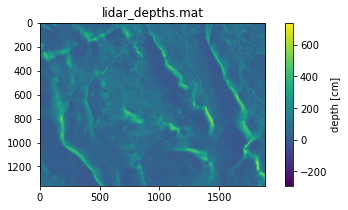

(1362, 1884)


In [213]:
# # step 1: create the X meter grid (center Xs and Ys) from the lidar dataset (1 m)
new_res = 1 # meter spacing for grid

[lidar_DATA, lidar_X, lidar_Y] = read_ground_data_mat(ground_data_folder+'lidar_depths.mat')
lidar_X = lidar_X.flatten()
lidar_Y = lidar_Y.flatten()

# determine where edges lie
edge_X_min = np.min(lidar_X)-0.5; edge_X_max = np.max(lidar_X)+0.5
edge_Y_top = np.max(lidar_Y)+0.5; edge_Y_bottom = np.min(lidar_Y)-0.5

grid_X = np.arange(edge_X_min+new_res/2, edge_X_max, new_res)
grid_Y = np.arange(edge_Y_top, edge_Y_bottom+new_res/2, -new_res)

plt.figure(figsize=(7,3)); plt.imshow(lidar_DATA); plt.title('lidar_depths.mat'); 
cbar = plt.colorbar(); cbar.set_label('depth [cm]'); plt.show()
print(lidar_DATA.shape)

In [214]:
# read in radar data and grab lidar data at all overlapping points
all_radar_dfs = pd.read_csv('/Users/jukesliu/Documents/POSTDOC/snow-radar/RY_output/coords/all_rds_lidar0removed.csv')

# subtract directly from lidar depths
x_idxs = []; y_idxs = []
for i in range(0, len(all_radar_dfs.UTMx)):
    x = all_radar_dfs.UTMx[i]; y = all_radar_dfs.UTMy[i]

    x_idxs.append(np.argmin(np.abs(grid_X-x)))
    y_idxs.append(np.argmin(np.abs(grid_Y-y)))
lidar_depths = lidar_DATA[y_idxs, x_idxs].flatten()

# 2) Read and display ground datasets

In [8]:
fname = 'cores_density.mat'
[DATA, X, Y] = read_ground_data_mat(ground_data_folder+fname)

In [87]:
# print(DATA)

### A: gridded data

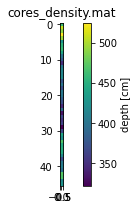

In [9]:
# for gridded data, imshow:
plt.figure(figsize=(7,3))
plt.imshow(DATA)
# plt.xticks(X.flatten())
# plt.yticks(Y.flatten())
cbar = plt.colorbar(); cbar.set_label('depth [cm]')
plt.title(fname)
plt.show()

### B: point data

In [461]:
# Remove out of bounds data
X_in = X[(X >= 519012) & (X <=520895) & (Y >= 4767635) & (Y <= 4768996)]
Y_in = Y[(X >= 519012) & (X <=520895) & (Y >= 4767635) & (Y <= 4768996)]
DATA_in = DATA[(X >= 519012) & (X <=520895) & (Y >= 4767635) & (Y <= 4768996)]

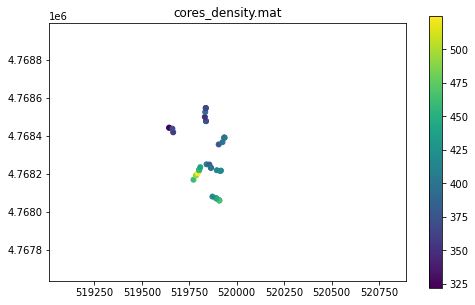

In [462]:
# for point/transect data, plot:
# list(zip(DATA, X< )
plt.figure(figsize=(8,5))
plt.scatter(X_in,Y_in,c=DATA_in.flatten(),s=25)
plt.colorbar()
plt.title(fname)
plt.gca().set_aspect('equal')
plt.xlim(519012,520895); plt.ylim(4767635,4768996)
plt.show()

222477428.3964394


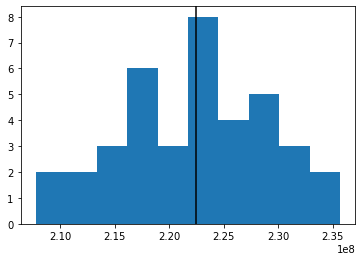

In [481]:
# if cored density, calculate velocity:
cored_density = DATA_in.flatten()/1000
calculated_velocity = np.sqrt((3e8**2)/(1+(1.7*cored_density) + (0.7*cored_density**2)))
print(np.nanmean(calculated_velocity))

plt.hist(calculated_velocity,bins=10)
plt.axvline(x=np.nanmean(calculated_velocity),color='k')
plt.show()

In [482]:
2.225e8

222500000.0

# 3) Resample gridded data

In [89]:
from scipy.interpolate import interp2d

(1362, 1884)
Resampled to new dimensions: (1362, 1884)


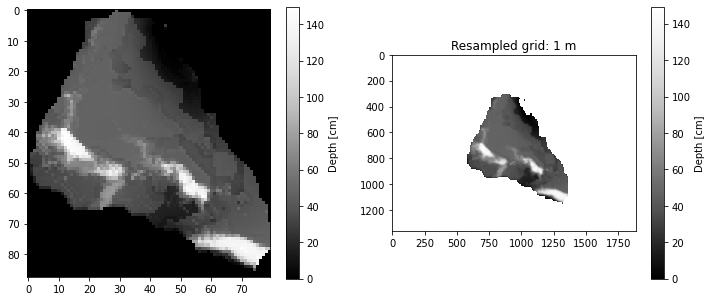

Save resampled grid to /Users/jukesliu/Documents/POSTDOC/snow-radar/ReynoldsMountain/ground_data/isnobal_SWE_1m.tif


In [90]:
outfile = fname[:-4]+'_'+str(new_res)+'m.tif'
outpath = ground_data_folder


# Create thew new x and y grid values using DEM bounds and the chipsize
resamp = np.zeros((len(grid_Y), len(grid_X))) # create an empty resampled DEM grid
print(resamp.shape)

# Resample to your new DEM bounds
f = interp2d(X.flatten(), Y.flatten(), DATA, fill_value=np.NaN) # create DEM interpolation object
resamp = f(grid_X,grid_Y) # resample the NIR data to the DSM coordinates
resamp = np.flipud(resamp) # flip up down
resamp[resamp==0.0] = np.NaN # convert 0 depths to NaNs
print("Resampled to new dimensions:",resamp.shape)

# Display the two DEMs as a visual check
fig, (ax1,ax2) = plt.subplots(1,2, figsize=(12,5))
im1 = ax1.imshow(DATA, cmap='Greys_r', vmin=0)
# ax1.set_title('Original DEM: '+str(refdem.transform[0])+' m') # original spatial resolution
fig.colorbar(im1, ax=ax1,label='Depth [cm]')

im2 = ax2.imshow(resamp, cmap='Greys_r', vmin=0)
ax2.set_title('Resampled grid: '+str(new_res)+' m') # new spatial resolution
fig.colorbar(im2, ax=ax2,label='Depth [cm]')
plt.show()

# Save the resampled DEM to georeferenced tif file
print("Save resampled grid to", outpath+outfile)
with rio.open(outpath+outfile,'w',
                  driver='GTiff',
                  height=resamp.shape[0], # new shape
                  width=resamp.shape[1], # new shape
                  dtype=resamp.dtype, # data type
                  count=1,
                  crs='EPSG:32611', # the EPSG for Reynolds Mounain
                  transform=rio.Affine(new_res, 0.0, edge_X_min, # modified transform
                                       0.0, -new_res, edge_Y_top)) as dst:
        dst.write(resamp, 1)

# 4) Compare datasets

In [4]:
# ground data files
ground_data_folder = '/Users/jukesliu/Documents/POSTDOC/snow-radar/ReynoldsMountain/ground_data/'
os.listdir(ground_data_folder)

['lidar_depths_1m.tif',
 'isnobal_SWE.mat',
 '.DS_Store',
 'lidar_depths.mat',
 'isnobal_depths_10m.tif.aux.xml',
 'lidar_depths_10m.tif',
 'cores_depths_3m.tif.aux.xml',
 'measured_depths.mat',
 'lidar_depths_3m.tif.aux.xml',
 'cores_depths.mat',
 'isnobal_depths_3m.tif',
 'measured_depths_3m.tif',
 'isnobal_depths_10m.tif',
 'cores_density.mat',
 'cores_SWE.mat',
 'isnobal_depths_1m.tif',
 'lidar_depths_3m.tif',
 'isnobal_depths.mat',
 'lidar_depths_10m.tif.aux.xml',
 'isnobal_SWE_1m.tif',
 'cores_depths_3m.tif']

### A: two grids of data

In [87]:
# read in tifs and subtract and plot
fname1 = 'isnobal_depths_1m.tif'
file1 = rio.open(ground_data_folder+fname1) # open 
data1 = file1.read(1) 

fname2 = 'isnobal_SWE_1m.tif'
file2 = rio.open(ground_data_folder+fname2) # open
data2 = file2.read(1) # read in the first and only band (elevations)

In [6]:
# # subtract
# plt.figure(figsize=(10,4))
# plt.imshow(data1-data2, cmap='RdBu',vmin=-400,vmax=400)
# cbar = plt.colorbar(); cbar.set_label('depth difference [cm]')
# plt.title(fname1+' - '+fname2)
# plt.show()

### B: points and gridded data

In [90]:
# # # read in tifs and subtract and plot
# fname1 = 'lidar_depths_1m.tif'
# file1 = rio.open(ground_data_folder+fname1) # open 
# data1 = file1.read(1) 

data1 = calculated_density

fname2 = 'cores_density.mat'
[DATA, X, Y] = read_ground_data_mat(ground_data_folder+fname2)
X = X.flatten(); Y = Y.flatten(); data2 = DATA.flatten()

# Remove out of bounds data
X_in = X[(X >= 519012) & (X <=520895) & (Y >= 4767635) & (Y <= 4768996)]
Y_in = Y[(X >= 519012) & (X <=520895) & (Y >= 4767635) & (Y <= 4768996)]
DATA_in = DATA[(X >= 519012) & (X <=520895) & (Y >= 4767635) & (Y <= 4768996)]

In [91]:
# find nearest idxs
x_idxs = []; y_idxs = []
for i in range(0, len(X_in)):
    x = X_in[i]; y = Y_in[i]

    x_idxs.append(np.argmin(np.abs(grid_X-x)))
    y_idxs.append(np.argmin(np.abs(grid_Y-y)))
# print(x_idxs, y_idxs)

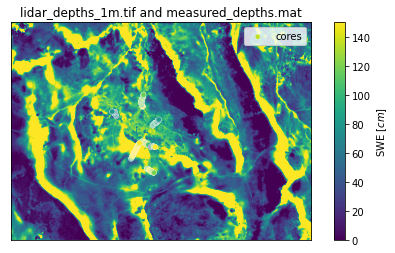

In [139]:
# plot
plt.figure(figsize=(8,4))
plt.imshow(data1,vmin=0, vmax=150)
cbar1 = plt.colorbar(); cbar1.set_label('SWE [$cm$]')
plt.scatter(x_idxs, y_idxs, c=DATA_in, marker='o',edgecolor='white',linewidth=0.2,s=25,vmin=0, vmax=150)
# cbar2 = plt.colorbar(); cbar2.set_label('measured depth [$cm$]')
plt.title(fname1+' and '+fname2)
plt.legend(['cores'])
plt.yticks([]); plt.xticks([])
plt.show()

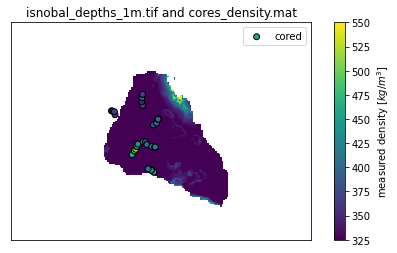

In [93]:
# compare densities only 
plt.figure(figsize=(8,4))
plt.imshow(data1,vmin=325, vmax=550)
#cbar1 = plt.colorbar(); cbar1.set_label('modeled density [$kg/m^3$]')
plt.scatter(x_idxs, y_idxs, c=DATA_in, marker='o',edgecolor='black',s=35,vmin=325, vmax=550)
cbar2 = plt.colorbar(); cbar2.set_label('measured density [$kg/m^3$]')
plt.title(fname1+' and '+fname2)
# plt.title('calculated densities vs. measured densities')
plt.legend(['cored'])
plt.yticks([]); plt.xticks([])
plt.show()

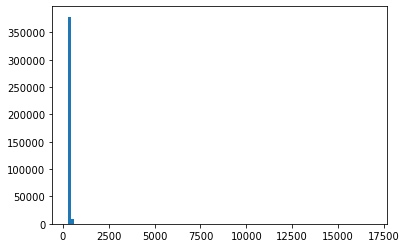

In [114]:
plt.hist(data1.flatten(),bins=100)
plt.show()

In [49]:
# grab difference in depth at points
gridded_depths_at_points = data1[y_idxs, x_idxs].flatten()
diff = gridded_depths_at_points - DATA_in.flatten()

plt.figure(figsize=(10,4))
plt.imshow(data1,vmin=0,vmax=150)
cbar1 = plt.colorbar(); cbar1.set_label('calculated density [$kg/m^3$]')
plt.scatter(x_idxs, y_idxs, c=diff, cmap='RdBu',marker='o',s=25,vmin=-50, vmax=50)
cbar2 = plt.colorbar(); cbar2.set_label('density difference [$kg/m^3$]')
plt.show()

# # linear regression
# r2_ground_lidar = r2_score(gridded_depths_at_points, DATA_in.flatten())
# rmse_ground_lidar = np.sqrt(mean_squared_error(gridded_depths_at_points, DATA_in.flatten()))
# # print(round(r2_ground_lidar,2), str(round(rmse_ground_lidar,2)))

# # histogram
# plt.figure(figsize=(6,4))
# plt.hist(diff,bins=30)
# plt.xlim(-250,250); plt.title('Distribution of depth differences'); plt.xlabel('Depth difference [cm]')
# plt.show()

# # plot 1 to 1 comparison
# plt.scatter(gridded_depths_at_points, DATA_in.flatten(), marker='.',color='g',alpha=1)
# plt.plot([0,1000],[0,1000],'k-')
# plt.xlim([0,400]); plt.ylim([0,400])
# plt.ylabel('measured depths [cm]'); plt.xlabel('lidar depths [cm]')
# plt.title('$r^2$ = '+str(round(r2_ground_lidar,2))+', RMSE = '+str(round(rmse_ground_lidar,2)))
# plt.gca().set_aspect('equal'); plt.tight_layout()
# # plt.savefig('/Users/jukesliu/Documents/POSTDOC/snow-radar/ReynoldsMountain/ground_lidar_1to1.jpg',dpi=200)
# plt.show()

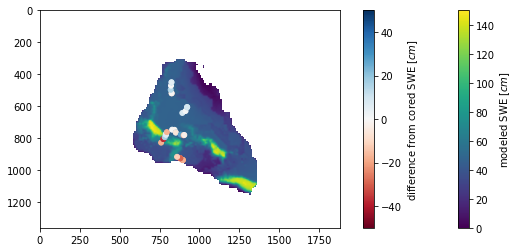

In [51]:
plt.figure(figsize=(10,4))
plt.imshow(data1,vmin=0,vmax=150)
cbar1 = plt.colorbar(); cbar1.set_label('modeled SWE [$cm$]')
plt.scatter(x_idxs, y_idxs, c=diff, cmap='RdBu',marker='o',s=25,vmin=-50, vmax=50)
cbar2 = plt.colorbar(); cbar2.set_label('difference from cored SWE [$cm$]')
# plt.title(fname1+' - '+fname2)
plt.show()

# 5) Compare radar data

### Compare directly with lidar data

In [163]:
# all_radar_dfs = all_radar_dfs[(all_radar_dfs.rd_id == 'rd02') | (all_radar_dfs.rd_id == 'rd03') | (all_radar_dfs.rd_id == 'rd04')]
# all_radar_dfs = all_radar_dfs.reset_index(drop=True)

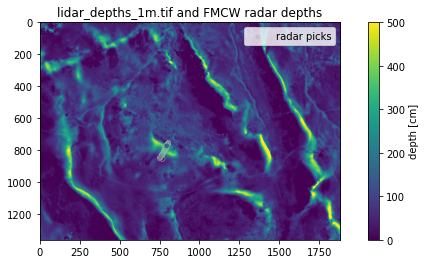

In [117]:
plt.figure(figsize=(10,4))
plt.imshow(data1,vmin=0, vmax=500)
cbar = plt.colorbar(); cbar.set_label('depth [cm]')
plt.scatter(x_idxs, y_idxs, c=all_radar_dfs.radar_depth_cm,marker='o',edgecolor='white',linewidth=0.2,s=25,vmin=0,vmax=500,alpha=0.1)
plt.title(fname1+' and FMCW radar depths')
plt.legend(['radar picks'])
plt.show()

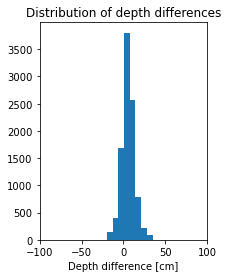

In [119]:
# grab difference in depth at points
gridded_depths_at_points = lidar_DATA[y_idxs, x_idxs].flatten()
diff = gridded_depths_at_points - (all_radar_dfs.radar_depth_cm)

plt.figure(figsize=(3,4))
plt.hist(diff,bins=30)
plt.xlim(-100,100); 
plt.title('Distribution of depth differences'); plt.xlabel('Depth difference [cm]')
plt.show()

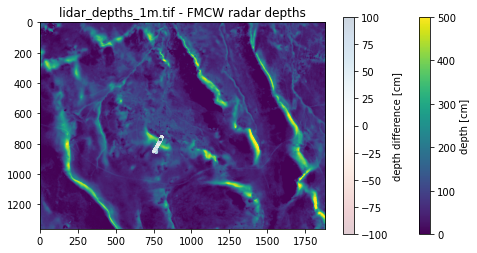

In [123]:
plt.figure(figsize=(8,4))
plt.imshow(data1,vmin=0, vmax=500)
cbar1 = plt.colorbar(); cbar1.set_label('depth [cm]')
plt.scatter(x_idxs, y_idxs, c=diff, cmap='RdBu',marker='o',linewidth=0,s=10,vmin=-100, vmax=100,alpha=0.2)
cbar2 = plt.colorbar(); cbar2.set_label('depth difference [cm]')
plt.title(fname1+' - FMCW radar depths')
plt.show()

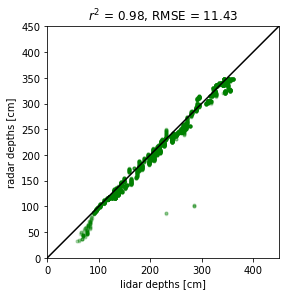

In [128]:
# plot 1 to 1 comparison
from sklearn.metrics import r2_score, mean_squared_error 

plt.scatter(gridded_depths_at_points, all_radar_dfs.radar_depth_cm, marker='.',color='g',alpha=0.1)
plt.plot([0,1000],[0,1000],'k-')
plt.xlim([0,450]); plt.ylim([0,450])
plt.ylabel('radar depths [cm]'); plt.xlabel('lidar depths [cm]')
plt.gca().set_aspect('equal'); plt.tight_layout()

r2 = r2_score(all_radar_dfs.radar_depth_cm,gridded_depths_at_points)
rmse = np.sqrt(mean_squared_error(all_radar_dfs.radar_depth_cm,gridded_depths_at_points))
plt.title('$r^2$ = '+str(round(r2,2))+', RMSE = '+str(round(rmse,2)))
# plt.savefig('/Users/jukesliu/Documents/POSTDOC/snow-radar/ReynoldsMountain/radar_lidar_1to1_1000scale_100size_1mod.jpg',dpi=200)
plt.show()

# 6) Compare cored density with radar inverted densities

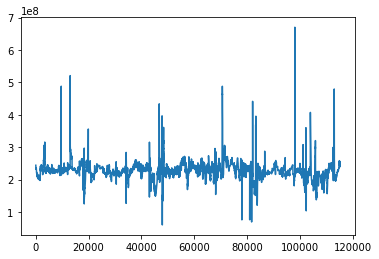

226940973.80509904


In [422]:
velocities = ((lidar_depths+41)/100)/(all_radar_dfs.TWT_ground/2 - all_radar_dfs.TWT_surf/2) # divide TWT by 2
plt.plot(velocities); plt.show()
print(np.nanmean(velocities))

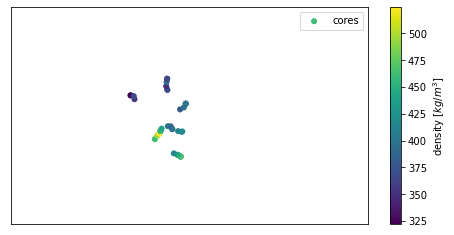

In [457]:
# read in cored data, grab coordinates
[cored_density, X, Y] = read_ground_data_mat(ground_data_folder+'cores_density.mat')
X = X.flatten(); Y = Y.flatten(); cored_density = cored_density.flatten()
# Remove out of bounds data
X_in = X[(X >= 519012) & (X <=520895) & (Y >= 4767635) & (Y <= 4768996)]
Y_in = Y[(X >= 519012) & (X <=520895) & (Y >= 4767635) & (Y <= 4768996)]
cored_density = cored_density[(X >= 519012) & (X <=520895) & (Y >= 4767635) & (Y <= 4768996)]

# find nearest idxs
core_x_idxs = []; core_y_idxs = []
for i in range(0, len(X_in)):
    x = X_in[i]; y = Y_in[i]

    core_x_idxs.append(np.argmin(np.abs(grid_X-x)))
    core_y_idxs.append(np.argmin(np.abs(grid_Y-y)))
# print(x_idxs, y_idxs)

# plot
plt.figure(figsize=(8,4))
plt.scatter(X_in, Y_in, c=cored_density, marker='o',s=25)
plt.legend(['cores']); cbar = plt.colorbar(); cbar.set_label('density [$kg/m^3$]')
plt.yticks([]); plt.xticks([])
plt.xlim(519012,520895); plt.ylim(4767635,4768996)
plt.show()

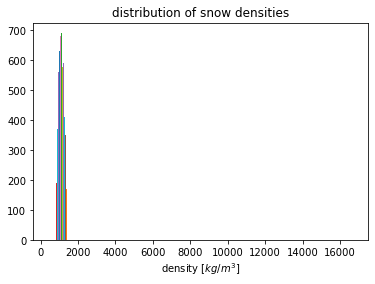

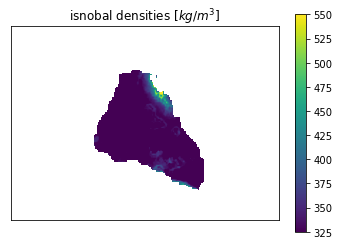

In [146]:
# calculation density from Isnobal depth and SWE
fname1 = 'isnobal_depths_1m.tif'
file1 = rio.open(ground_data_folder+fname1) # open 
data1 = file1.read(1) 

fname2 = 'isnobal_SWE_1m.tif'
file2 = rio.open(ground_data_folder+fname2) # open
data2 = file2.read(1) # read in the first and only band (elevations)

calculated_density = (np.array(data2)/100)/(np.array(data1)/100)*1000 # SWE [m] / snow depths [m] * 1000 to convert to kg/m3

plt.figure(figsize=(6,4))
plt.hist(calculated_density)
plt.title('distribution of snow densities')
plt.xlabel('density [$kg/m^3$]')
plt.show()

plt.figure(figsize=(6,4))
plt.imshow(calculated_density, cmap='viridis', vmin=325,vmax=550)
cbar = plt.colorbar(); #cbar.set_label('depth difference [cm]')
plt.xticks([]); plt.yticks([])
plt.title('isnobal densities [$kg/m^3$]')
plt.show()

399.97010442401734
-2828.541532995446


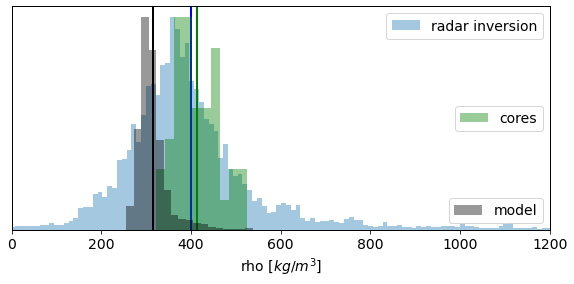

In [424]:
# solve the quadratic equation for rho
a = 0.7
b = 1.7
c = 1-(3e8**2/(velocities**2))
rho1 = (-b + np.sqrt((b**2)-4*a*c))/(2*a)
rho2 = (-b - np.sqrt((b**2)-4*a*c))/(2*a)

print(np.nanmean(rho1*1000)); print(np.nanmean(rho2*1000)) # multiply by 1000 to convert from g/cc to kg/m^3

# plot density distributions
fs = 14; a=0.4
fig, ax = plt.subplots(figsize=(8,4))
ax2 = ax.twinx(); ax3 = ax.twinx()
# ax.hist(rho2*1000,bins=50)
ax.hist(rho1*1000, bins=500,alpha=a) 
ax.legend(['radar inversion'],loc='upper right',fontsize=fs)
# ax.axvline(x=np.nanmedian(rho1*1000),color='blue')
    
ax2.hist(cored_density, bins=10, color='green',alpha=a)
ax2.set_yticks([]); ax3.set_yticks([]); ax.set_yticks([])
ax3.hist(calculated_density.flatten(),bins=1000, color='black',alpha=a)
ax2.legend(['cores'],loc='center right',fontsize=fs); ax3.legend(['model'],loc='lower right', fontsize=fs)

# mean values
ax.axvline(x=np.nanmean(rho1*1000),linewidth=2, color='blue')
ax2.axvline(x=np.nanmean(cored_density),linewidth=2,color='green')
ax3.axvline(x=np.nanmean(calculated_density), linewidth=2, color='black')
plt.xlim(0,1200)
ax.set_xlabel("rho [$kg/m^3$]", fontsize=fs)
plt.tight_layout()
ax.tick_params(axis='both',labelsize=fs)
plt.savefig('/Users/jukesliu/Documents/POSTDOC/snow-radar/ReynoldsMountain/density_distrib_comparison_RME.jpg',dpi=200)
plt.show()

### Explore spatial averaging

In [377]:
def weighted_avg(xpoints,ypoints,values,xarray,yarray,winsize):
    import numpy as np
    # calculated weighted average of the values at coordinates xarray,yarray within an N-meter radius of x0,y0
    # INPUTS:
    # xpoints = x-coordinate of the points at center of the window [m]
    # ypoints = y-coordinate of the point at center of the window [m]
    # values = values to average
    # xarray = x-coordinates of the values [m]
    # yarray = y-coordinates fo the values [m]
    # winsize = N-meter window (radius of circular window)
    # OUTPUTS:
    # mean_vals = list of weighted mean values
    # val_stds = list of std of values within each window
    
    sigma = winsize/2 
    mean_vals = []; val_stds = []
    for i in range(0, len(xpoints)):
        x0 = xpoints[i]; y0 = ypoints[i]
        
        # calculate distances to the point
        distance = euclidian_dist(x0,y0,xarray,yarray)
        weights = np.exp(-distance**2 / (2 * sigma**2))
        weighted_values = values*weights
        weighted_sum = sum(weighted_values)

        if len(values) != len(weights):
            raise ValueError("Values and weights lists must have the same length.")

        sum_of_weights = sum(weights)
        if sum_of_weights == 0:
            raise ZeroDivisionError("Sum of weights cannot be zero.")
        mean_val = weighted_sum / sum_of_weights
        val_std = np.nanstd(weighted_values)

        # add to lists
        mean_vals.append(mean_val); val_stds.append(val_std)
        
    return mean_vals, val_stds

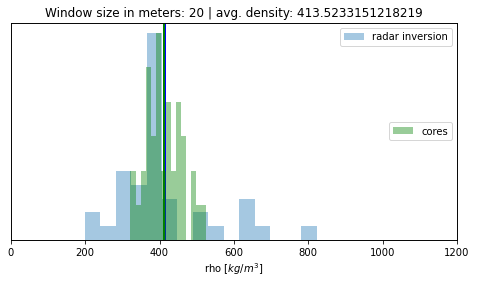

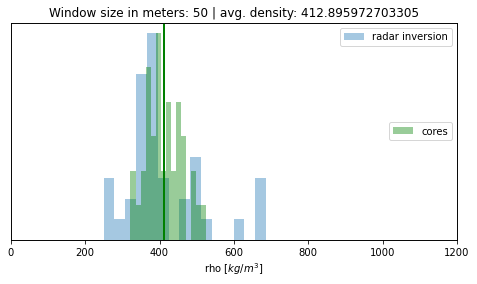

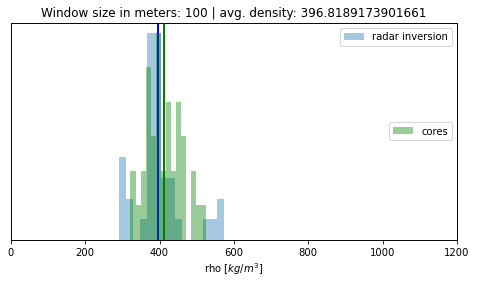

In [287]:
for winsize in [20,50,100]:
    [radar_avg_TWT, TWT_std] = weighted_avg(X_in,Y_in,(all_radar_dfs.TWT_ground/2 - all_radar_dfs.TWT_surf/2), all_radar_dfs.UTMx, all_radar_dfs.UTMy,winsize)
    [avg_lidar_depths, lidar_std] = weighted_avg(X_in,Y_in,lidar_depths,all_radar_dfs.UTMx, all_radar_dfs.UTMy,winsize)
    velocities = ((np.array(avg_lidar_depths)+41)/100)/np.array(radar_avg_TWT)

    # solve the quadratic equation for rho
    a = 0.7
    b = 1.7
    c = 1-(3e8**2/(velocities**2))
    rho1 = (-b + np.sqrt((b**2)-4*a*c))/(2*a)
    rho2 = (-b - np.sqrt((b**2)-4*a*c))/(2*a)

    # plot density distributions
    a=0.4
    fig, ax = plt.subplots(figsize=(8,4))
    ax2 = ax.twinx(); #ax3 = ax.twinx()
    # ax.hist(rho2*1000,bins=50)
    ax.hist(rho1*1000, bins=15,alpha=a) 
    ax.legend(['radar inversion'],loc='upper right')
    # ax.axvline(x=np.nanmedian(rho1*1000),color='blue')

    ax2.hist(cored_density, bins=15, color='green',alpha=a)
    ax2.set_yticks([]); ax3.set_yticks([]); ax.set_yticks([])
#     ax3.hist(data1.flatten(),bins=1000, color='black',alpha=a)
    ax2.legend(['cores'],loc='center right'); ax3.legend(['model'],loc='lower right')

    # mean values
    ax.axvline(x=np.nanmean(rho1*1000),linewidth=2, color='blue')
    ax2.axvline(x=np.nanmean(cored_density),linewidth=2,color='green')
#     ax3.axvline(x=np.nanmean(data1.flatten()), linewidth=2, color='black')
    plt.xlim(0,1200)
    ax.set_xlabel("rho [$kg/m^3$]")
    ax.set_title('Window size in meters: '+str(winsize)+' | avg. density: '+str(np.nanmean(rho1*1000)))
    plt.show()

In [281]:
# optimize window size!
from scipy import optimize

def fit_weightedavg_window(winsize):
    [radar_avg_TWT, radar_std] = weighted_avg(X_in,Y_in,(all_radar_dfs.TWT_surf/2-all_radar_dfs.TWT_ground/2), all_radar_dfs.UTMx, all_radar_dfs.UTMy,winsize)
    [avg_lidar_depths, lidar_std] = weighted_avg(X_in,Y_in,lidar_depths,all_radar_dfs.UTMx, all_radar_dfs.UTMy,winsize)
    velocities = ((np.array(avg_lidar_depths)+41)/100)/np.array(radar_avg_TWT)
    
    
    # solve the quadratic equation for rho
    a = 0.7
    b = 1.7
    c = 1-(3e8**2/(velocities**2))
    rho1 = (-b + np.sqrt((b**2)-4*a*c))/(2*a)
    rho2 = (-b - np.sqrt((b**2)-4*a*c))/(2*a)
    density_values = rho1*1000
    
    RMSE = np.sqrt(np.nanmean((cored_density - density_values))**2)
    print(winsize, RMSE)
    
    return RMSE

In [363]:
# run the optimization
# optimize.fmin_powell(fit_weightedavg_window,100,direc=(5,5), bounds=()) # minimum step
for guess in [50]:
    result = optimize.minimize(fit_weightedavg_window,guess,method='Powell',bounds=([(20,200)])) # bounds
    print(str(guess)+'m window initial guess:')
    print(result)

ValueError: operands could not be broadcast together with shapes (38,) (115,) 

In [375]:
# def weighted_avg_pt(x0,y0,values,xarray,yarray,winsize):
#     import numpy as np
#     # calculated weighted average of the values at coordinates xarray,yarray within an N-meter radius of x0,y0
#     # INPUTS:
#     # xpoints = x-coordinate of the points at center of the window [m]
#     # ypoints = y-coordinate of the point at center of the window [m]
#     # values = values to average
#     # xarray = x-coordinates of the values [m]
#     # yarray = y-coordinates fo the values [m]
#     # winsize = N-meter window (radius of circular window)
#     # OUTPUTS:
#     # mean_vals = list of weighted mean values
#     # val_stds = list of std of values within each window
    
#     sigma = winsize/2 
#     mean_vals = []; val_stds = []
        
#     distance = euclidian_dist(x0,y0,xarray,yarray)
#     weights = np.exp(-distance**2 / (2 * sigma**2))
#     weighted_values = values*weights
#     weighted_sum = sum(weighted_values)

#     if len(values) != len(weights):
#         raise ValueError("Values and weights lists must have the same length.")

#     sum_of_weights = sum(weights)
#     if sum_of_weights == 0:
#         raise ZeroDivisionError("Sum of weights cannot be zero.")
#     mean_val = weighted_sum / sum_of_weights
#     val_std = np.nanstd(weighted_values)

#     return mean_val

In [387]:
def pts_in_window(x0,y0,values,xarray,yarray,winsize):        
    # calculate distances to the point
    distance = np.array(euclidian_dist(x0,y0,xarray,yarray))
    pts_in_window = values[distance <= (winsize/2)] # grab points within the 1/2 window radius

    return pts_in_window

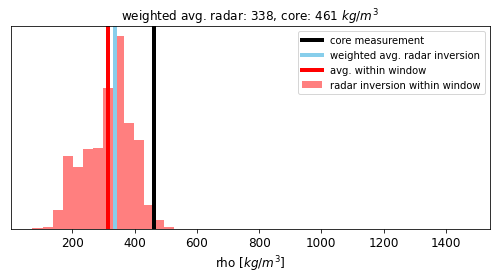

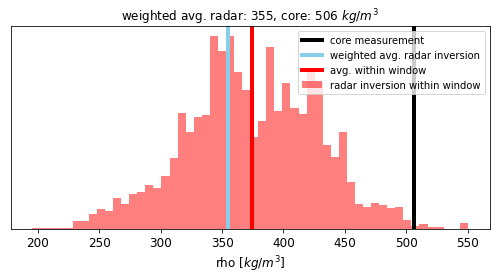

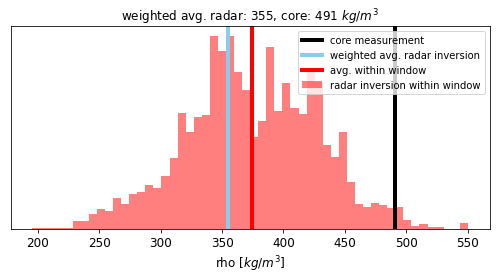

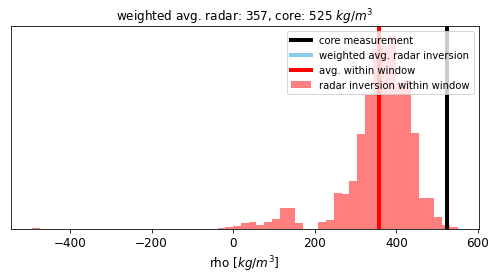

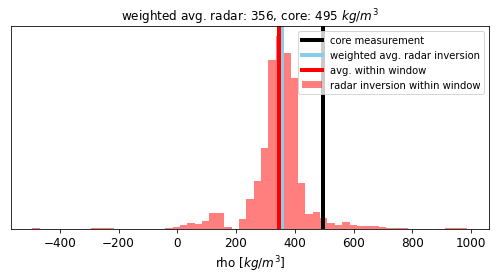

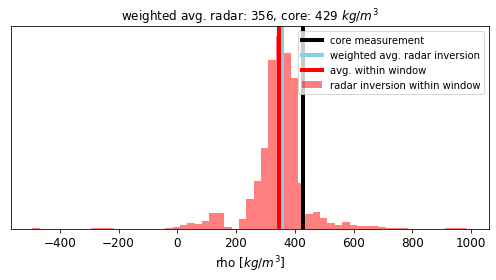

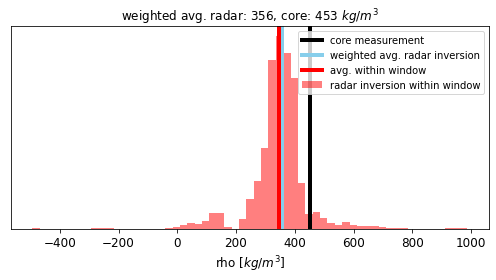

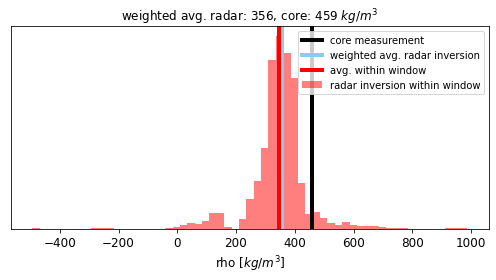

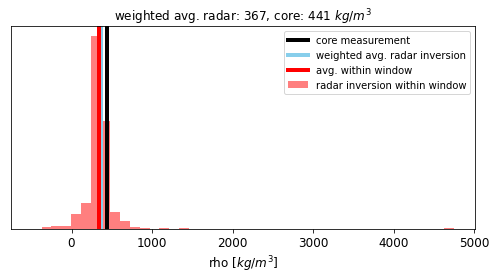

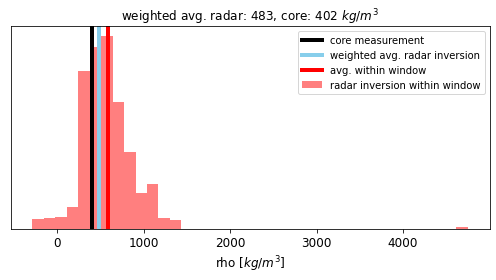

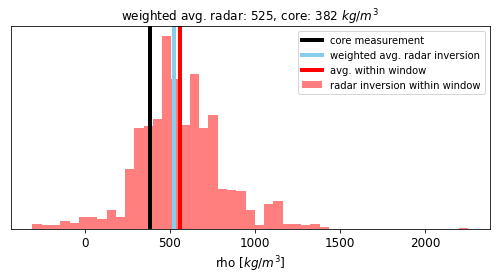

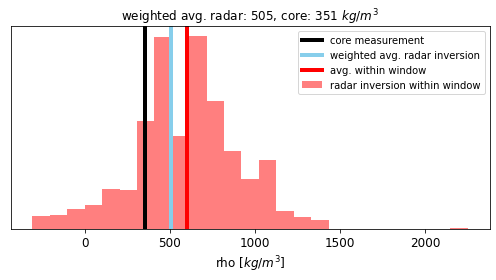

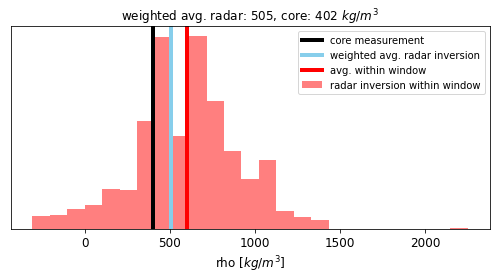

No radar measurements within 50m of core.


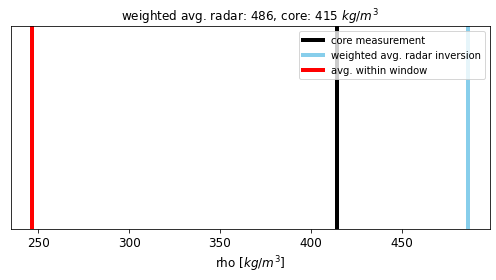

No radar measurements within 50m of core.


/var/folders/mr/7f69f7y50zj85n420pyvh8cr0000gq/T/ipykernel_11241/348206049.py:40: RuntimeWarning: Mean of empty slice
  ax.axvline(x=np.nanmean(window_rho), color='r', linewidth=lw)


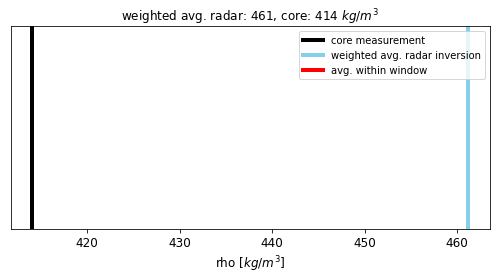

No radar measurements within 50m of core.


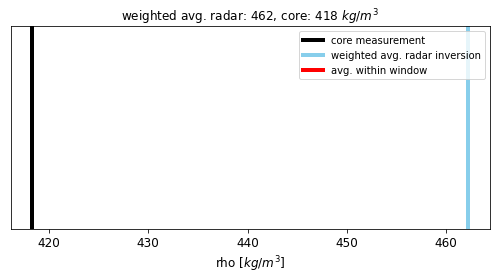

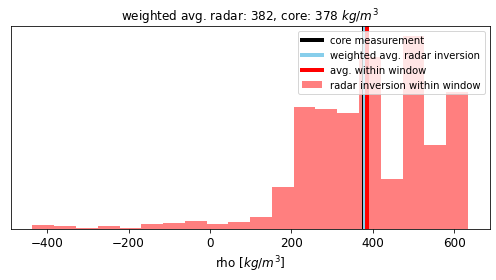

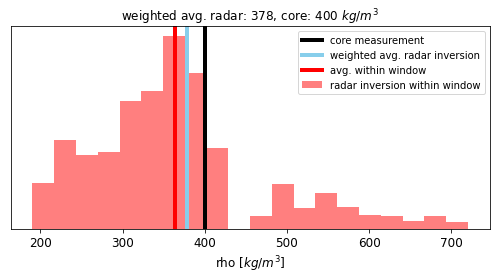

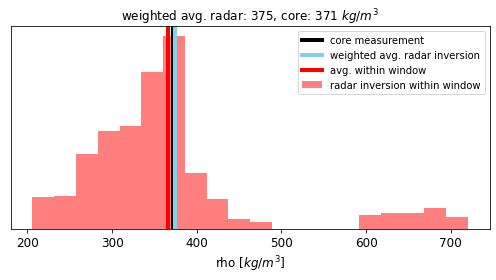

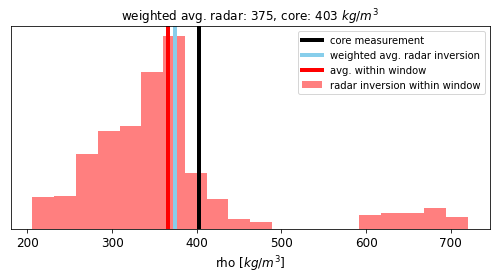

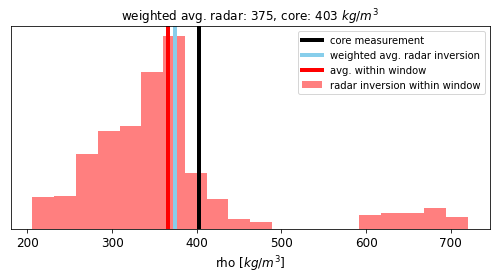

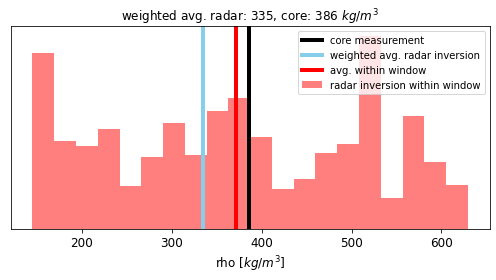

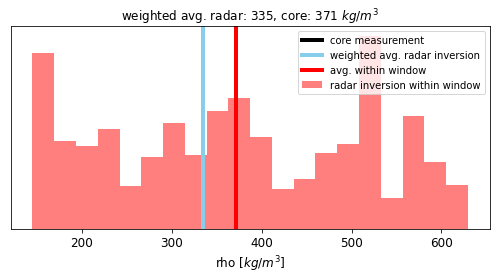

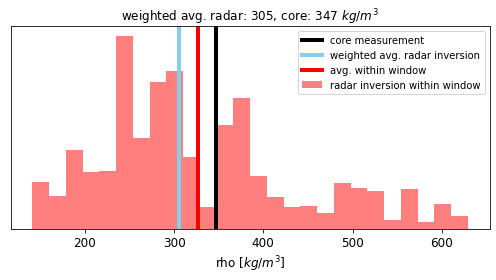

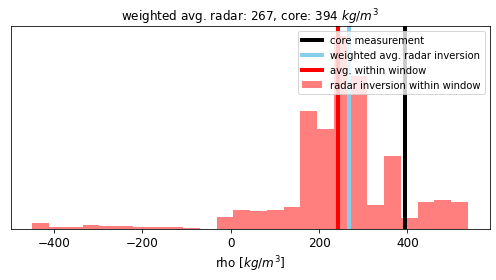

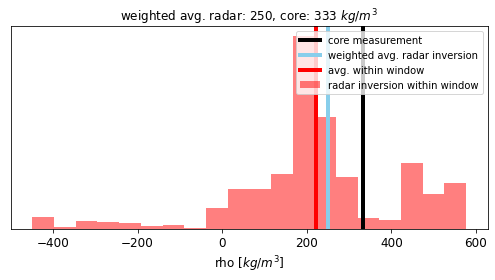

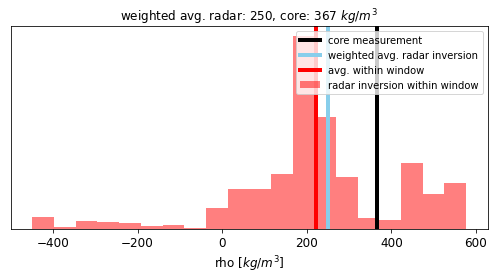

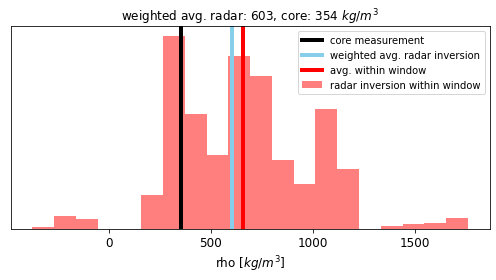

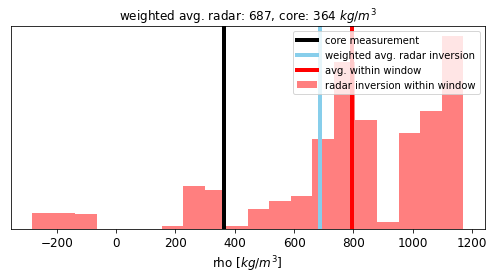

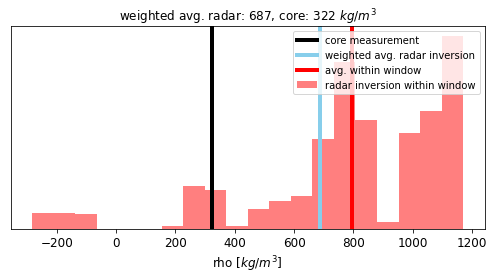

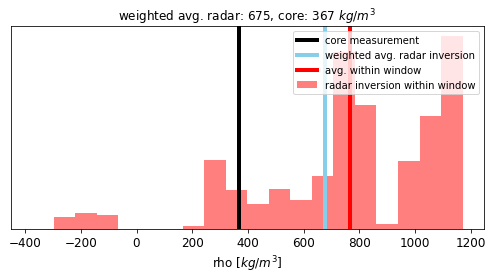

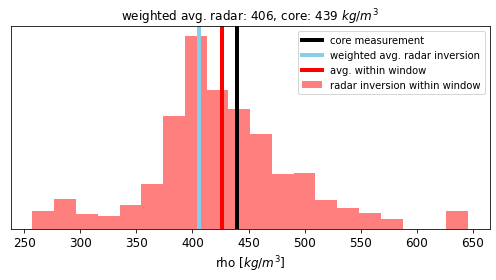

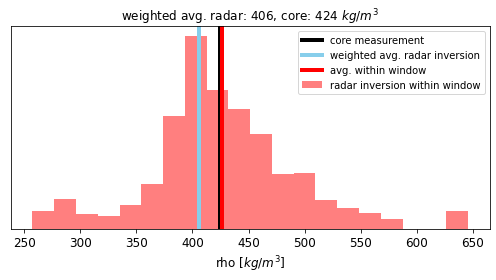

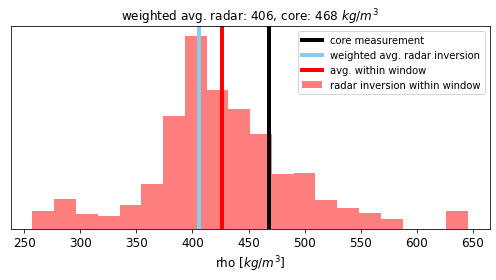

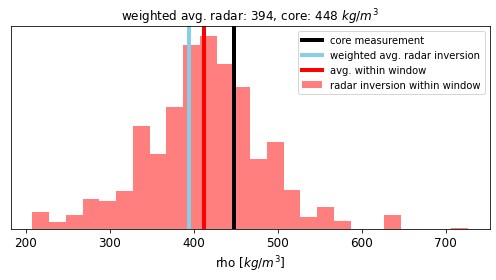

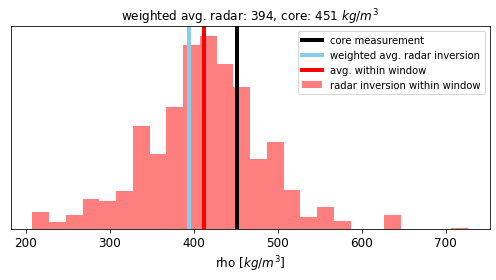

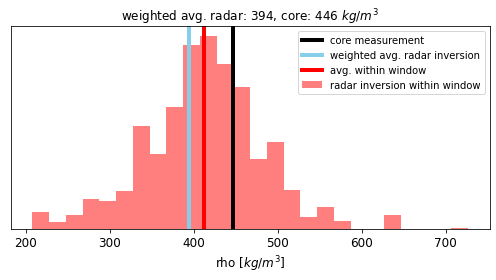

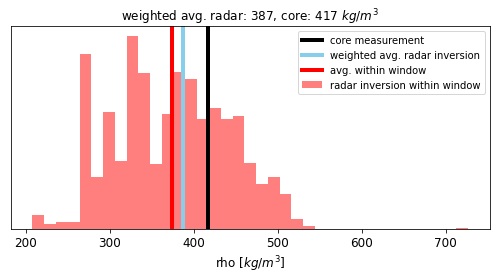

In [449]:
# compare distribution of densities  within window
windowsize=50
density_diff_at_cores = []

for i in range(0, len(cored_density)):
    x = X_in[i]; y = Y_in[i]; rho = cored_density[i]
    
    # calculate all densities within window (unweighted)
    window_radar_TWT = pts_in_window(x,y,(all_radar_dfs.TWT_ground/2 - all_radar_dfs.TWT_surf/2), all_radar_dfs.UTMx, all_radar_dfs.UTMy,windowsize)
    window_lidar_depths = pts_in_window(x,y,lidar_depths, all_radar_dfs.UTMx, all_radar_dfs.UTMy,windowsize)
    velocities = ((np.array(window_lidar_depths)+41)/100)/np.array(window_radar_TWT)
    a = 0.7; b = 1.7; c = 1-(3e8**2/(velocities**2)) # solve the quadratic formula for rho
    rho1 = (-b + np.sqrt((b**2)-4*a*c))/(2*a); rho2 = (-b - np.sqrt((b**2)-4*a*c))/(2*a)
    window_rho = rho1*1000 # calculate mean radar density
    
    # calculate weighted average radar TWT & lidar depths
    [radar_avg_TWT, TWT_std] = weighted_avg([x],[y],(all_radar_dfs.TWT_ground/2 - all_radar_dfs.TWT_surf/2), all_radar_dfs.UTMx, all_radar_dfs.UTMy,windowsize)
    [avg_lidar_depths, lidar_std] = weighted_avg([x],[y],lidar_depths,all_radar_dfs.UTMx, all_radar_dfs.UTMy,windowsize)
    velocities = ((np.array(avg_lidar_depths)+41)/100)/np.array(radar_avg_TWT)
    a = 0.7; b = 1.7; c = 1-(3e8**2/(velocities**2)) # solve the quadratic formula for rho
    rho1 = (-b + np.sqrt((b**2)-4*a*c))/(2*a); rho2 = (-b - np.sqrt((b**2)-4*a*c))/(2*a)
    weighted_avg_rho = np.nanmean(rho1*1000) # calculate mean radar density
    
    # calculate the differences and append to list
    density_diff = rho - weighted_avg_rho # subtract avg. radar inverted density from core measurement
    density_diff_at_cores.append(density_diff)
   
    # plot density distributions
    lw = 4; fs = 12
    fig, ax = plt.subplots(figsize=(7,4))
    ax.axvline(x=rho, color='k', linewidth=lw)
    nbins = round(len(window_rho)/200)
    if nbins == 0:
        print('No radar measurements within '+str(windowsize)+'m of core.')
    else:
        if nbins < 20:
            nbins = 20 # set minimum bin number
        ax.hist(window_rho, color='r', bins=nbins, alpha=0.5)
    ax.axvline(x=weighted_avg_rho, color='skyblue', linewidth=lw)
    ax.axvline(x=np.nanmean(window_rho), color='r', linewidth=lw)
    ax.legend(['core measurement','weighted avg. radar inversion','avg. within window', 'radar inversion within window'],fontsize=fs-2, loc='upper right')
    ax.set_xlabel("rho [$kg/m^3$]", fontsize=fs)
    ax.set_yticks([]); plt.tick_params(labelsize=fs)
#     ax.set_xlim(0,800)
    plt.title('weighted avg. radar: '+str(round(weighted_avg_rho))+', core: '+str(round(rho))+' $kg/m^3$', fontsize=fs)
    plt.tight_layout()
    plt.savefig('/Users/jukesliu/Documents/POSTDOC/snow-radar/ReynoldsMountain/density_at_cores/'+str(x)+'east_'+str(y)+'north.jpg',dpi=200)
    plt.show()

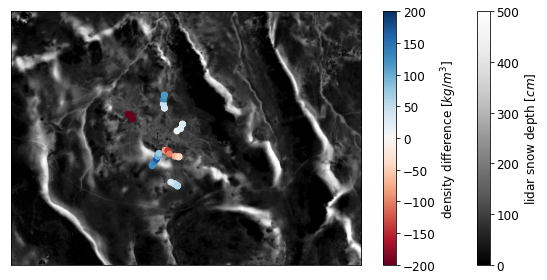

In [463]:
# plot this spatially
fs = 12
plt.figure(figsize=(8,4))
plt.imshow(lidar_DATA,cmap = 'Greys_r',vmin=0,vmax=500) # plot lidar depth map
cbar1 = plt.colorbar(); cbar1.ax.tick_params(labelsize=fs); cbar1.set_label('lidar snow depth [$cm$]',fontsize=fs)

plt.scatter(core_x_idxs, core_y_idxs, c=density_diff_at_cores, cmap='RdBu',marker='o',s=35,vmin=-200, vmax=200)
cbar2 = plt.colorbar(); cbar2.ax.tick_params(labelsize=fs); cbar2.set_label('density difference [$kg/m^3$]',fontsize=fs)

plt.xticks([]); plt.yticks([])
plt.tight_layout()
plt.savefig('/Users/jukesliu/Documents/POSTDOC/snow-radar/ReynoldsMountain/density_diff_at_cores.jpg',dpi=200)
plt.show()

# Compare weighted average radar depths vs. measurements within a window

In [332]:
# read in radar data
all_radar_dfs = pd.read_csv('/Users/jukesliu/Documents/POSTDOC/snow-radar/RY_output/coords/all_rds_lidar0removed.csv')
drift_dfs = all_radar_dfs[(all_radar_dfs.rd_id == 'rd02') | (all_radar_dfs.rd_id == 'rd03') | (all_radar_dfs.rd_id == 'rd04')]
drift_dfs = drift_dfs.reset_index(drop=True)

# grab the lidar depths
x_idxs = []; y_idxs = []
for i in range(0, len(drift_dfs.UTMx)):
    x = drift_dfs.UTMx[i]; y = drift_dfs.UTMy[i]
    x_idxs.append(np.argmin(np.abs(grid_X-x)))
    y_idxs.append(np.argmin(np.abs(grid_Y-y)))
drift_lidar_depths = lidar_DATA[y_idxs, x_idxs].flatten()

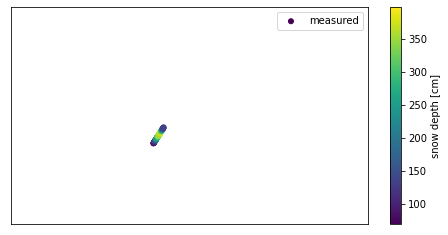

In [333]:
# select measured data in drift
[measured_depth, X, Y] = read_ground_data_mat(ground_data_folder+'measured_depths.mat')
X = X.flatten(); Y = Y.flatten(); measured_depth = measured_depth.flatten()
X_in = X[(X >= 519761) & (X <=519818.15) & (Y >= 4768141.64) & (Y <= 4768241.1195)]
Y_in = Y[(X >= 519761) & (X <=519818.15) & (Y >= 4768141.64) & (Y <= 4768241.1195)]
measured_depth  = measured_depth[(X >= 519761) & (X <=519818.15) & (Y >= 4768141.64) & (Y <= 4768241.1195)]

# plot
plt.figure(figsize=(8,4))
plt.scatter(X_in, Y_in, c=measured_depth, marker='o',s=25)
plt.legend(['measured']); cbar = plt.colorbar(); cbar.set_label('snow depth [cm]')
plt.yticks([]); plt.xticks([])
plt.xlim(519012,520895); plt.ylim(4767635,4768996)
plt.show()

In [339]:
# calculate distance along drift
drift_x0 = np.array(X_in)[0]
drift_y0 = np.array(Y_in)[0]
dist_along_drift_m = euclidian_dist(drift_x0, drift_y0, X_in, Y_in)

# calculated weighted averages within window size
window = 10 # meters
[radar_avg, radar_std] = weighted_avg(X_in,Y_in,drift_dfs.radar_depth_cm,drift_dfs.UTMx, drift_dfs.UTMy, window)
[lidar_avg, lidar_std] = weighted_avg(X_in,Y_in,drift_lidar_depths,drift_dfs.UTMx,drift_dfs.UTMy,window)
[probe_avg, probe_std] = weighted_avg(X_in,Y_in,measured_depth,X_in,Y_in, window)

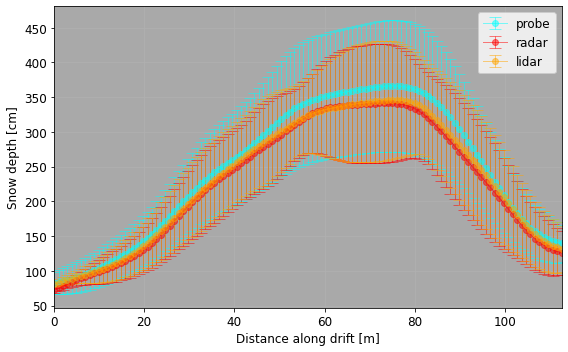

In [340]:
# plot snow depths along drift
fs = 12; a = 0.5; cs = 6; lw=1
fig, ax = plt.subplots(figsize=(8,5))
ax.errorbar(dist_along_drift_m, probe_avg, yerr=probe_std,
             marker='o',color='cyan',linewidth=lw,label='probe',capsize=cs,alpha=a) # measurements
ax.errorbar(dist_along_drift_m, radar_avg, yerr=radar_std,
            marker='o',color='red',linewidth=lw,label='radar',capsize=cs,alpha=a) # radar
ax.errorbar(dist_along_drift_m, lidar_avg, yerr=lidar_std,
             marker='o',color='orange',linewidth=lw,label='lidar',capsize=cs,alpha=a) # lidar
ax.legend(fontsize=fs)
plt.tick_params(labelsize=fs)
plt.ylabel('Snow depth [cm]',fontsize=fs); plt.xlabel('Distance along drift [m]', fontsize=fs)
plt.xlim(0,np.nanmax(dist_along_drift_m))
ax.set_facecolor('darkgrey'); plt.grid()
plt.tight_layout()
# plt.savefig('/Users/jukesliu/Documents/POSTDOC/snow-radar/ReynoldsMountain/drift_depths_comparison.jpg',dpi=200)
plt.show()

7.58808653922763 %
17.27902330053601
7.457635938535283 %
17.003138848885026
7.568809124853266 %
17.260387193246064


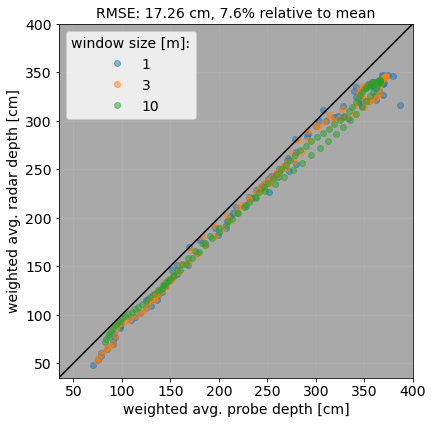

In [374]:
# plot weighted average radar depth vs. measured depth by window size
minval=35; maxval = 400
a=0.5; fs = 14
fig, ax = plt.subplots(figsize=(6,6))
for window in [1,3,10]:
    [radar_avg, radar_std] = weighted_avg(X_in,Y_in,drift_dfs.radar_depth_cm,drift_dfs.UTMx, drift_dfs.UTMy, window)
    [probe_avg, probe_std] = weighted_avg(X_in,Y_in,measured_depth,X_in,Y_in, window)
    [lidar_avg, lidar_std] = weighted_avg(X_in,Y_in,drift_lidar_depths,drift_dfs.UTMx,drift_dfs.UTMy,window)
    
    # probe
    ax.plot(probe_avg, 
            radar_avg,
            'o', alpha=a,label=window)
    RMSE = np.sqrt(np.nanmean((np.array(radar_avg) - np.array(probe_avg)))**2)
    
#     # lidar
#     ax.plot(lidar_avg, 
#             radar_avg,
#             's', alpha=a,label=window)
#     RMSE = np.sqrt(np.nanmean((np.array(radar_avg) - np.array(lidar_avg)))**2)
    
    percent_err = RMSE/np.nanmean(radar_avg)*100
    print(percent_err, '%')
    print(RMSE)
    
ax.plot([minval,maxval],[minval,maxval],'k-')
plt.grid()
plt.legend(title='window size [m]:',title_fontsize=fs,fontsize=fs); plt.tick_params(labelsize=fs)
plt.gca().set_aspect('equal')
plt.xlim(minval,maxval); plt.ylim(minval,maxval)
plt.title('RMSE: '+str(round(RMSE,2))+' cm, '+str(round(percent_err,1))+'% relative to mean',fontsize=fs)
# plt.title('weighted avg. radar depth vs. weighted avg. probe depth [cm]',fontsize=fs)
plt.xlabel('weighted avg. probe depth [cm]', fontsize=fs); plt.ylabel('weighted avg. radar depth [cm]', fontsize=fs)
plt.tight_layout(); ax.set_facecolor('darkgrey')
plt.savefig('/Users/jukesliu/Documents/POSTDOC/snow-radar/ReynoldsMountain/drift_depths_1to1_radar_probe.jpg',dpi=200)
plt.show()

# Plot data from drift:

/Users/jukesliu/opt/anaconda3/envs/newautoriftenv/lib/python3.9/site-packages/pandas/core/generic.py:5507: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self[name] = value


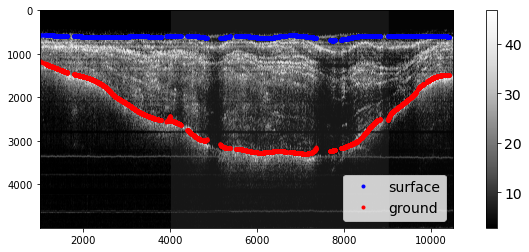

In [391]:
# load radagrams
rd_array_path = '/Users/jukesliu/Documents/POSTDOC/snow-radar/ReynoldsMountain/ProcessedMay25_xyz/' 
rds_drift = []; radarpicks_drift = []
for rd_id in ['rd02','rd03','rd04']: # grab data from the three rd sections
    rd = np.load(glob.glob(rd_array_path+rd_id+'_preprocessed.npy')[0])
    rds_drift.append(rd)
    
    sub_left = 1000; sub_right = 11500
    # grab the radar picks
    radarpicks = all_radar_dfs[all_radar_dfs.rd_id == rd_id]  # from all_radar_dfs CSV file
    if rd_id == 'rd02':
        radarpicks.rd_xidx = radarpicks.rd_xidx - sub_left
    elif rd_id == 'rd03':
        radarpicks.rd_xidx = radarpicks.rd_xidx + 5000-sub_left
        radarpicks = radarpicks[radarpicks.Iground > 1600] # get rid of outlier
    elif rd_id == 'rd04':
        radarpicks.rd_xidx = radarpicks.rd_xidx + 10000-sub_left
    radarpicks_drift.append(radarpicks)
radarpicks_drift = pd.concat(radarpicks_drift) # stitch data together
radarpicks_drift = radarpicks_drift.reset_index(drop=True)
rd_drift = np.hstack(rds_drift)[:,sub_left:sub_right] # stitch rd images together and subset to the drift

# plot
fs=14; a=1
fig, ax = plt.subplots(figsize=(12,4))
im = ax.imshow(rd_drift,cmap='Greys_r'); 
ax.plot(radarpicks_drift.rd_xidx, radarpicks_drift.Isurf, 'b.',alpha=a)
ax.plot(radarpicks_drift.rd_xidx, radarpicks_drift.Iground-323, 'r.',alpha=a)
ax.legend(['surface','ground','lidar'],loc='lower right',fontsize=fs)
cbar = plt.colorbar(im); cbar.ax.tick_params(labelsize=fs)
plt.xlim(sub_left,sub_right-sub_left)
plt.show()

In [397]:
# grab lidar depth and convert to pixels
# subtract directly from lidar depths
x_idxs = []; y_idxs = []
for i in range(0, len(radarpicks_drift.UTMx)):
    x = radarpicks_drift.UTMx[i]; y = radarpicks_drift.UTMy[i]

    x_idxs.append(np.argmin(np.abs(grid_X-x)))
    y_idxs.append(np.argmin(np.abs(grid_Y-y)))
lidar_depths = lidar_DATA[y_idxs, x_idxs].flatten()

# convert lidar depths to pixels
velocity = 226940973.80509904*100 # cm/s
TWT_interval = 1.1418660481770834e-11 # s
lidar_uncert = 20 # cm
pixel_diffs = np.array(lidar_depths*2/velocity/TWT_interval) # calculate lidar depths in pixels
lidar_uncert_pixels = lidar_uncert*2/velocity/TWT_interval
# convert vertical axis to depth
# convert to distance along drift

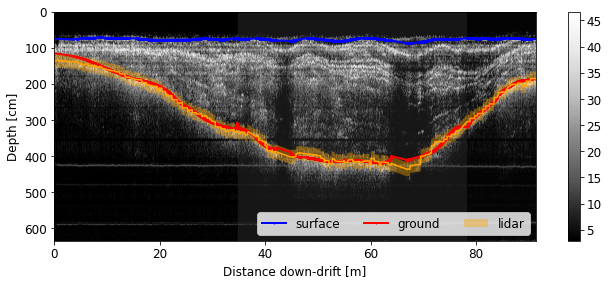

In [458]:
# plot
fs=12; a=1
fig, ax = plt.subplots(figsize=(10,4))
im = ax.imshow(rd_drift,cmap='Greys_r'); 
ax.plot(radarpicks_drift.rd_xidx, radarpicks_drift.Isurf, 'b.-',markersize=2,linewidth=2,alpha=a) # surface
ax.plot(radarpicks_drift.rd_xidx, radarpicks_drift.Iground-323, 'r.-',markersize=2,linewidth=2,alpha=a) # ground
ax.fill_between(radarpicks_drift.rd_xidx, radarpicks_drift.Isurf+pixel_diffs-lidar_uncert_pixels, # lidar uncert
                radarpicks_drift.Isurf+pixel_diffs+lidar_uncert_pixels,
                color='orange', edgecolor='none', alpha=0.4)
ax.plot(radarpicks_drift.rd_xidx, radarpicks_drift.Isurf+pixel_diffs, '-',color='orange',alpha=a) # lidar
ax.legend(['surface','ground','lidar'],ncol=3,loc='lower right',fontsize=fs)
cbar = plt.colorbar(im); cbar.ax.tick_params(labelsize=fs)
plt.xlim(sub_left,sub_right-sub_left)
plt.xticks(np.arange(0,sub_right,2301),np.arange(0,100,20),fontsize=fs); # force x-tick labels
plt.yticks(np.arange(0,5000,787.5),np.arange(0,601,100),fontsize=fs)# force y-tick labels
plt.xlabel('Distance down-drift [m]',fontsize=fs); plt.ylabel('Depth [cm]',fontsize=fs)
plt.tight_layout()
plt.savefig('/Users/jukesliu/Documents/POSTDOC/snow-radar/ReynoldsMountain/drift_fig.jpg',dpi=300)
plt.show()

In [423]:
drift_x0 = radarpicks_drift.iloc[0].UTMx
drift_y0 = radarpicks_drift.iloc[0].UTMy

dist_downdrift = euclidian_dist(drift_x0, drift_y0, radarpicks_drift.UTMx, radarpicks_drift.UTMy)
print(dist_downdrift)

0        0.000000
1        0.014118
2        0.028321
3        0.042619
4        0.056988
          ...    
9716    84.487467
9717    84.480207
9718    84.472913
9719    84.465581
9720    84.458222
Length: 9721, dtype: float64


In [449]:
np.arange(0,5000,787.5)*0.127

array([  0.    , 100.0125, 200.025 , 300.0375, 400.05  , 500.0625,
       600.075 ])

In [450]:
rd_drift.shape

(5000, 10500)

In [445]:
100/0.127

787.4015748031496

In [383]:
# add in probed depths

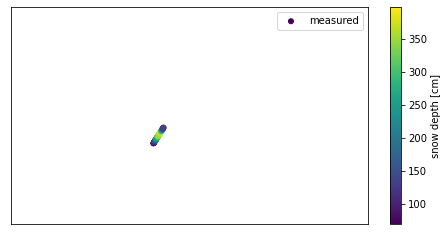

In [307]:
# select measured data in drift
measured_df = pd.read_csv(ground_data_folder+'measured_depths.csv')
X = measured_df.UTMx; Y = measured_df.UTMy; measured_depth = measured_df.measured_depth_cm
X_in = X[(X >= 519763.7) & (X <=519820.8) & (Y >= 4768136.7) & (Y <= 4768240.9)]
Y_in = Y[(X >= 519763.7) & (X <=519820.8) & (Y >= 4768136.7) & (Y <= 4768240.9)]
measured_depth = measured_depth[(X >= 519763.7) & (X <=519820.8) & (Y >= 4768136.7) & (Y <= 4768240.9)]

# plot
plt.figure(figsize=(8,4))
plt.scatter(X_in, Y_in, c=measured_depth, marker='o',s=25)
plt.legend(['measured']); cbar = plt.colorbar(); cbar.set_label('snow depth [cm]')
plt.yticks([]); plt.xticks([])
plt.xlim(519012,520895); plt.ylim(4767635,4768996)
plt.show()

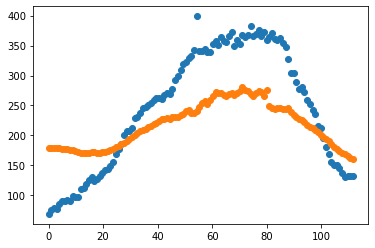

In [308]:
drift_x0 = np.array(X_in)[0]
drift_y0 = np.array(Y_in)[0]
dist_along_drift_m = euclidian_dist(drift_x0, drift_y0, X_in, Y_in)

plt.plot(dist_along_drift_m, measured_depth, 'o')
plt.plot(dist_along_drift_m, weighted_avg(np.array(X_in),np.array(Y_in),all_radar_dfs.radar_depth_cm, all_radar_dfs.UTMx, all_radar_dfs.UTMy,100),'o')
plt.show()

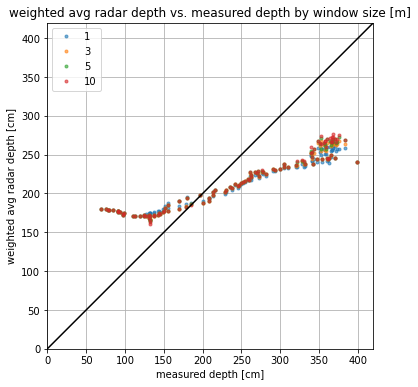

In [275]:
# plot weighted average radar depth vs. measured depth by window size
maxval = 420
a=0.6
fig, ax = plt.subplots(figsize=(6,6))
for winsize in [1,3,5,10]:
    ax.plot(measured_depth, 
            weighted_avg(np.array(X_in),np.array(Y_in),all_radar_dfs.radar_depth_cm, all_radar_dfs.UTMx, all_radar_dfs.UTMy,winsize),
            '.', alpha=a,label=winsize)
ax.plot([0,maxval],[0,maxval],'k-')
plt.gca().set_aspect('equal')
plt.xlim(0,maxval); plt.ylim(0,maxval)
plt.grid()
plt.legend()
plt.title('weighted avg radar depth vs. measured depth by window size [m]')
plt.xlabel('measured depth [cm]'); plt.ylabel('weighted avg radar depth [cm]')
plt.show()